# Weather Autoregressive MLP

> This notebook is converted from the Python script `05_weather_autoregressive_mlp.py`.

# Notebook Description

This notebook demonstrates autoregressive multi-layer perceptron (MLP) modeling for weather prediction using PyTorch. It covers:
- Data loading and preparation
- Model definition (including residual blocks)
- Training with autoregressive roll-out
- Evaluation and visualization of results

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
from auxtorch import count_parameters, get_device
from pretorch import CustomMLP, ResBlockMLP
from torch.utils.data import DataLoader
from torch.utils.data.dataset import Dataset
from tqdm import tqdm

# Weather Dataset Class

In [ ]:
# ===== WeatherDataset Class =====
class WeatherDataset(Dataset):
    def __init__(self, dataset_file, day_range, split_date, train_test="train"):
        # parse user input in the class
        self.day_range = day_range
        # read and fix dataset
        df = pd.read_csv(dataset_file)
        df["Date"] = pd.to_datetime(df["Date"])
        df.set_index("Date", inplace=True)
        # normalize the dataset
        df_mean = df.mean()
        df_std = df.std()
        df_norm = (df - df_mean) / df_std
        # store mean and std
        self.mean = torch.tensor(df_mean.to_numpy()).reshape(1, -1)
        self.std = torch.tensor(df_std.to_numpy()).reshape(1, -1)
        # split normalized dataset based on train_test variable
        if train_test == "train":
            self.dataset = df_norm[df_norm.index < split_date]
        elif train_test == "test":
            self.dataset = df_norm[df_norm.index >= split_date]
        else:
            ValueError("train_test should be either train or test")

    def __getitem__(self, index):
        # Index a range of days
        end_index = index + self.day_range
        current_series = self.dataset.iloc[index:end_index]
        day_tensor = torch.LongTensor(current_series.index.day.to_numpy())
        month_tensor = torch.LongTensor(current_series.index.month.to_numpy())
        data_values = torch.FloatTensor(current_series.values)
        return day_tensor, month_tensor, data_values

    def __len__(self):
        return self.dataset.shape[0] - self.day_range


# Define Constants

In [2]:
# ===== Define Constants =====
DATASET_FILE = "https://raw.githubusercontent.com/LukeDitria/pytorch_tutorials/refs/heads/main/section12_sequential/data/weather.csv"
SPLIT_DATE = "2023-01-01"
DAY_RANGE = 15
DAYS_IN = 14
EPOCHS = 300
BATCH_SIZE = 32
LEARNING_RATE = 0.001
SHUFFLE_TRAIN = True
SHUFFLE_TEST = False

# Prepare Data

Load and split the weather dataset into training and testing sets using the custom `WeatherDataset` class. Print the number of examples in each split. Create PyTorch DataLoaders for batching.

In [3]:
# ===== Prepare Data =====
dataset_train = WeatherDataset(
    dataset_file=DATASET_FILE,
    day_range=DAY_RANGE,
    split_date=pd.to_datetime(SPLIT_DATE),
    train_test="train",
)

dataset_test = WeatherDataset(
    dataset_file=DATASET_FILE,
    day_range=DAY_RANGE,
    split_date=pd.to_datetime(SPLIT_DATE),
    train_test="test",
)

print(f"Number of training examples: {len(dataset_train)}")
print(f"Number of testing examples: {len(dataset_test)}")

data_loader_train = DataLoader(
    dataset=dataset_train, batch_size=BATCH_SIZE, shuffle=SHUFFLE_TRAIN, drop_last=True
)
data_loader_test = DataLoader(
    dataset=dataset_test, batch_size=BATCH_SIZE, shuffle=SHUFFLE_TEST, drop_last=True
)

Number of training examples: 3480
Number of testing examples: 412


# Visualize Data

Plot the maximum daily temperature for both training and testing sets to visualize the data distribution and split.

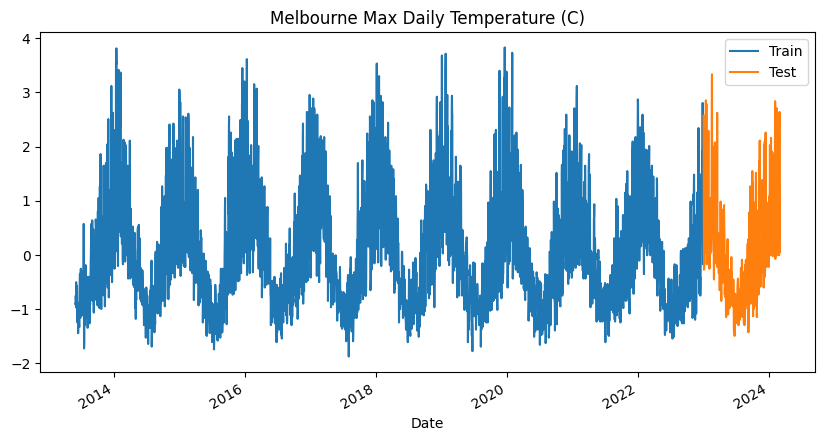

In [4]:
# ===== Visualize Data =====
fig = plt.figure(figsize=(10, 5))
_ = plt.title("Melbourne Max Daily Temperature (C)")
_ = dataset_train.dataset["Maximum temperature (Degree C)"].plot()
_ = dataset_test.dataset["Maximum temperature (Degree C)"].plot()
_ = plt.legend(["Train", "Test"])

# Define Models

Define two neural network architectures:
1. `ARResMLP`: Autoregressive MLP with residual blocks
2. `ResMLP`: Reference MLP with residual blocks

Both models use custom MLP and residual block modules for sequence modeling.

In [5]:
# ===== Define Models =====
class ARResMLP(nn.Module):
    def __init__(self, seq_len, output_size, block_output_size, num_blocks=1):
        super().__init__()
        flatten_seq_len = seq_len * 2
        self.mlp = CustomMLP(
            input_dim=flatten_seq_len,
            hidden_dims=(flatten_seq_len * 4,),
            output_dim=block_output_size,
            activation=nn.ELU,
            use_layernorm=True,
        )
        blocks = [
            ResBlockMLP(block_output_size, block_output_size) for _ in range(num_blocks)
        ]
        self.res = nn.Sequential(*blocks)
        self.fc_out = nn.Linear(block_output_size, output_size)
        self.act = nn.ELU()

    def forward(self, input_seq):
        input_seq = input_seq.reshape(input_seq.shape[0], -1)
        x = self.mlp(input_seq)
        x = self.act(self.res(x))
        return self.fc_out(x)


class ResMLP(nn.Module):
    def __init__(self, seq_len, output_size, num_blocks=1):
        super(ResMLP, self).__init__()
        # Compute the length of the sequence data
        seq_data_len = seq_len * 2
        # Define the input MLP with two fully connected layers and normalization
        self.input_mlp = nn.Sequential(
            nn.Linear(seq_data_len, 4 * seq_data_len),
            nn.ELU(),
            nn.LayerNorm(4 * seq_data_len),
            nn.Linear(4 * seq_data_len, 128),
        )
        # Define the sequence of residual blocks
        blocks = [ResBlockMLP(128, 128) for _ in range(num_blocks)]
        self.res_blocks = nn.Sequential(*blocks)
        # Final output fully connected layer
        self.fc_out = nn.Linear(128, output_size)
        # Activation function
        self.act = nn.ELU()

    def forward(self, input_seq):
        # Reshape the input sequence to be a flat vector
        input_seq = input_seq.reshape(input_seq.shape[0], -1)
        # Pass the input through the input MLP
        input_vec = self.input_mlp(input_seq)
        # Pass the output through the residual blocks and activation function
        x = self.act(self.res_blocks(input_vec))
        # Compute the final output
        return self.fc_out(x)


# Initialize Models

Set up the computation device (CPU/GPU). Instantiate both models and print their parameter counts for reference.

In [6]:
# ===== Initialize Models =====
device = get_device()

model_reference = ResMLP(seq_len=DAYS_IN, output_size=2).to(device)
count_parameters(model_reference)

model = ARResMLP(
    seq_len=DAYS_IN, output_size=2, block_output_size=128, num_blocks=1
).to(device)
count_parameters(model)

Using Apple Silicon GPU


51666

# Initialize Training Objects

Create the optimizer (`Adam`), loss function (`MSELoss`), and a logger for tracking training loss.

In [7]:
# ===== Initialize Training Objects =====
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
loss_fn = nn.MSELoss()
training_loss_logger = []

# Training Loop

Train the autoregressive model over multiple epochs:
1. For each batch, perform autoregressive roll-out for future prediction
2. Update the input sequence with model predictions
3. Compute and backpropagate loss
4. Log training loss for analysis

The inner training loop implements autoregressive prediction with the following steps:

- **Loop iterations**: Runs `DAY_RANGE - DAYS_IN` times per batch sequence
- **Single-step prediction**: Each iteration predicts the next day's values (2 features: rainfall and temperature)
- **Sequence update**: After each prediction:
    - Remove the oldest day from the input sequence
    - Append the new prediction to the end of the sequence
    - Maintain constant sequence length of `DAYS_IN` days
- **Autoregressive rollout**: Generates `DAY_RANGE - DAYS_IN` consecutive predictions into the future
- **Error accumulation**: Unlike teacher forcing, the model uses its own predictions as input for subsequent steps
- **Learning objective**: Trains the model to handle multi-step prediction while accounting for its own prediction errors

This approach ensures the model learns robust long-term forecasting by experiencing and adapting to its own prediction uncertainties during training.

In [8]:
# ===== Training Loop =====

# iterate over epochs
for epoch in tqdm(range(EPOCHS), desc="Epochs", leave=True, position=0):
    # set model to training mode
    model.train()
    # iterate over dataloader
    for day, month, datas in tqdm(
        data_loader_train, desc="Training", leave=False, position=1
    ):
        # output some info for debugging
        # dates = [
        #     f"{d}-{m}" for d, m in zip(day.numpy().flatten(), month.numpy().flatten())
        # ]
        # print(dates)
        # print(f"datas shape: {datas.shape}")
        # break

        # extract starting input sequence data - i.e. xs
        sequence_xs = datas[:, :DAYS_IN, :].to(device)
        # Initialize the loss for the current batch
        loss = 0
        # Iterate over the remaining sequence to predict the next day values
        # This loop will iterate DAY_RANGE - DAYS_IN times. For each iteration, it predicts the next day's values (single step prediction, here consisting of two values). Then it updates the input sequence by removing the oldest date and adding the new prediction. This will repeat DAY_RANGE - DAYS_IN times before exiting the loop and go and pull then next sequence from the dataloader. In other words we are going to autoregress DAY_RANGE - DAYS_IN times, i.e. generate DAY_RANGE - DAYS_IN autoregressive predictions. Stop at day DAYS_IN and predict DAY_RANGE - DAYS_IN out in the future. Every prediction takes its place at the end of the sequence and the oldest date is removed from the start of the sequence. That way the input sequence is always DAYS_IN long. This is opposite to teacher forcing where the true value is always added to the end of the sequence. this way, the model learns to predict X-steps out taking into consideration its own errors
        for i in range(DAY_RANGE - DAYS_IN):
            # print(i)
            # print(f"sequence_xs\n: {sequence_xs}")
            # break

            # Get the target sequence block for the next day
            sequence_ys = datas[:, i + DAYS_IN].to(device)
            # print(f"sequence_ys: {sequence_ys}")

            # Make a prediction using the model
            preds = model(sequence_xs)
            # Compute the loss for the current prediction
            loss += loss_fn(preds, sequence_ys)

            # Update the input sequence by removing the oldest date and adding the new prediction
            # Detach the new sequence to prevent backpropagation through the old sequence
            sequence_xs = torch.cat(
                (sequence_xs[:, 1:, :], preds.unsqueeze(1)), 1
            ).detach()
            # print()

        # Average the accumulated loss over the number of steps
        loss /= i + 1
        # Zero the gradients before performing backpropagation
        optimizer.zero_grad()
        # Perform backpropagation to compute gradients
        loss.backward()
        # Update the model parameters using the optimizer
        optimizer.step()
        # Log the training loss for later analysis
        training_loss_logger.append(loss.item())


Epochs: 100%|██████████| 300/300 [04:32<00:00,  1.10it/s]


# Plot Train Loss

Visualize the training loss over epochs to monitor model convergence.

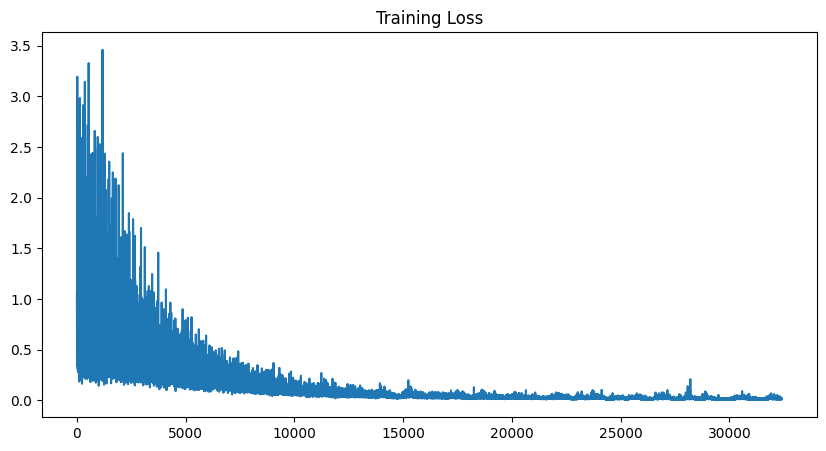

In [9]:
# ===== Plot Train Loss =====

_ = plt.figure(figsize=(10, 5))
_ = plt.plot(training_loss_logger)
_ = plt.title("Training Loss")

# Autoregressive Prediction Roll-Out

Perform autoregressive prediction on the test set:
- Roll out predictions step-by-step using the trained model
- Unnormalize predictions and ground truth for comparison

In [10]:
# ===== Autoregressive Prediction Roll-Out =====

# Convert the test dataset values to a PyTorch tensor
data_tensor = torch.FloatTensor(dataset_test.dataset.values)
# Initialize a list to log predictions
log_predictions = []
# Set the model to evaluation mode
model.eval()
# Disable gradient calculation for the prediction process
with torch.no_grad():
    # Extract the initial sequence block to be used as input for the model
    # - unsqueeze(0) adds a batch dimension to the input
    seq_block = data_tensor[:DAYS_IN, :].unsqueeze(0).to(device)

    # Iterate over the sequence to predict the next day values
    for i in range(data_tensor.shape[0] - DAYS_IN):
        # Make predictions using the model
        data_pred = model(seq_block)
        # Log the prediction
        log_predictions.append(data_pred.cpu())
        # Update the input sequence by removing the oldest date and adding the new prediction
        seq_block = torch.cat((seq_block[:, 1:, :], data_pred.unsqueeze(1)), 1)

# Concatenate the logged predictions into a single tensor
predictions_cat = torch.cat(log_predictions)
# Unnormalize the predictions using the dataset's standard deviation and mean
un_norm_predictions = (predictions_cat * dataset_test.std) + dataset_test.mean
# Unnormalize the original data using the dataset's standard deviation and mean
un_norm_data = (data_tensor * dataset_test.std) + dataset_test.mean
# Trim the initial sequence from the unnormalized data to match the length of predictions
un_norm_data = un_norm_data[DAYS_IN:]

# Evaluation

Evaluate model performance:
- Compute test mean squared error (MSE)
- Plot ground truth vs. predictions for rainfall and temperature

Test MSE value 42.39


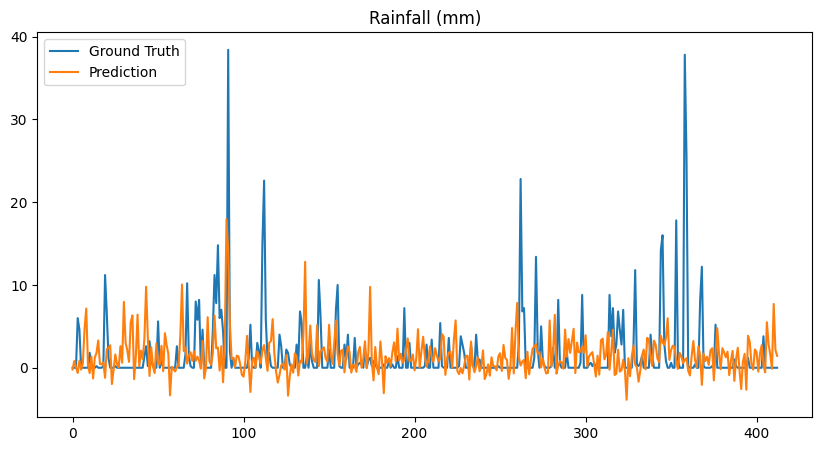

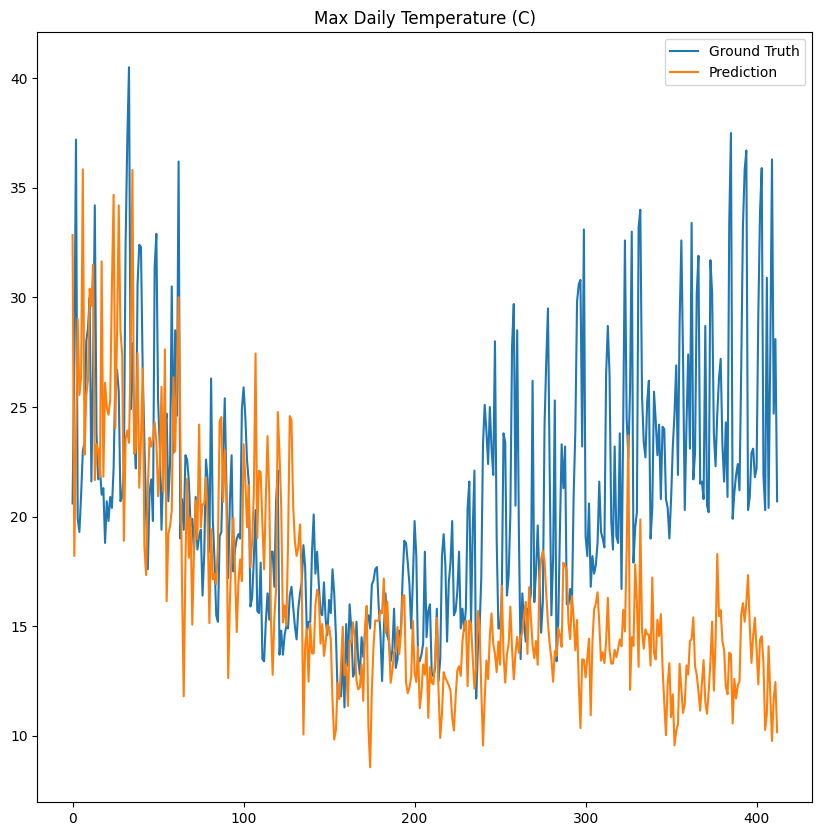

In [11]:
# ===== Evaluation =====

test_mse = (un_norm_data - un_norm_predictions).pow(2).mean().item()
print("Test MSE value %.2f" % test_mse)

_ = plt.figure(figsize=(10, 5))
_ = plt.plot(un_norm_data[:, 0])
_ = plt.plot(un_norm_predictions[:, 0])
_ = plt.title("Rainfall (mm)")
_ = plt.legend(["Ground Truth", "Prediction"])

_ = plt.figure(figsize=(10, 10))
_ = plt.plot(un_norm_data[:, 1])
_ = plt.plot(un_norm_predictions[:, 1])
_ = plt.title("Max Daily Temperature (C)")
_ = plt.legend(["Ground Truth", "Prediction"])